In [1]:
from datasets import load_dataset
db = load_dataset("ag_news",split="train")
docs = list(db["text"])

/info/etu/m2/s2101052/miniconda3/envs/ETE/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from embeddingTopicEvaluatorLib.models.top2vec_wrapper import TopicModelEvaluatorTop2Vec
from embeddingTopicEvaluatorLib.metrics.diversity import diversity
from embeddingTopicEvaluatorLib.metrics.retrieval import retrieval
from embeddingTopicEvaluatorLib.metrics.coherence import coherence
from embeddingTopicEvaluatorLib.config.config import settings

2026-03-09 17:53:22.855118: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 17:53:22.905803: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 17:53:26.044010: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
config=settings.TOP2VEC_CONFIG
config["TOP2VEC"]["n_components"]

10

In [4]:
models_topics = TopicModelEvaluatorTop2Vec(docs)

2026-03-09 17:53:39,139 - top2vec - INFO - Pre-processing documents for training
2026-03-09 17:53:47,498 - top2vec - INFO - Downloading paraphrase-multilingual-MiniLM-L12-v2 model
2026-03-09 17:53:51,226 - top2vec - INFO - Creating joint document/word embedding
2026-03-09 17:55:14,443 - top2vec - INFO - Creating lower dimension embedding of documents
2026-03-09 17:56:06,396 - top2vec - INFO - Finding dense areas of documents
2026-03-09 17:56:11,375 - top2vec - INFO - Finding topics
Reducing topics: 100%|██████████| 1391/1391 [07:01<00:00,  3.30it/s]


In [5]:
print("Diversity : ",diversity(models_topics))
print("Coherence : ",coherence(models_topics))
print("Retrieval : ",retrieval(models_topics,docs))

Diversity :  0.7263435
Coherence :  {0: np.float32(0.73351485), 1: np.float32(0.7131952), 2: np.float32(0.75178975), 3: np.float32(0.60311615), 4: np.float32(0.6950496), 5: np.float32(0.64889145), 6: np.float32(0.64740634), 7: np.float32(0.6005265), 8: np.float32(0.7861708), 9: np.float32(0.8095707), 10: np.float32(0.7360437), 11: np.float32(0.66827226), 12: np.float32(0.9767161), 13: np.float32(0.53769517), 14: np.float32(0.7833479), 15: np.float32(0.7850199), 16: np.float32(0.6991696), 17: np.float32(0.7533405), 18: np.float32(0.73191386), 19: np.float32(0.45540598), 20: np.float32(0.7093367), 21: np.float32(0.8637017), 22: np.float32(0.59435135), 23: np.float32(0.6124352), 24: np.float32(0.63343525), 25: np.float32(0.6822463), 26: np.float32(0.7835448), 27: np.float32(0.69340163), 28: np.float32(0.7392451), 29: np.float32(0.66877943), 30: np.float32(0.56119764), 31: np.float32(0.70717376), 32: np.float32(0.59164256), 33: np.float32(0.7676151), 34: np.float32(0.7173122), 35: np.float

Réduction UMAP en 2D en cours... (ça prend quelques secondes)


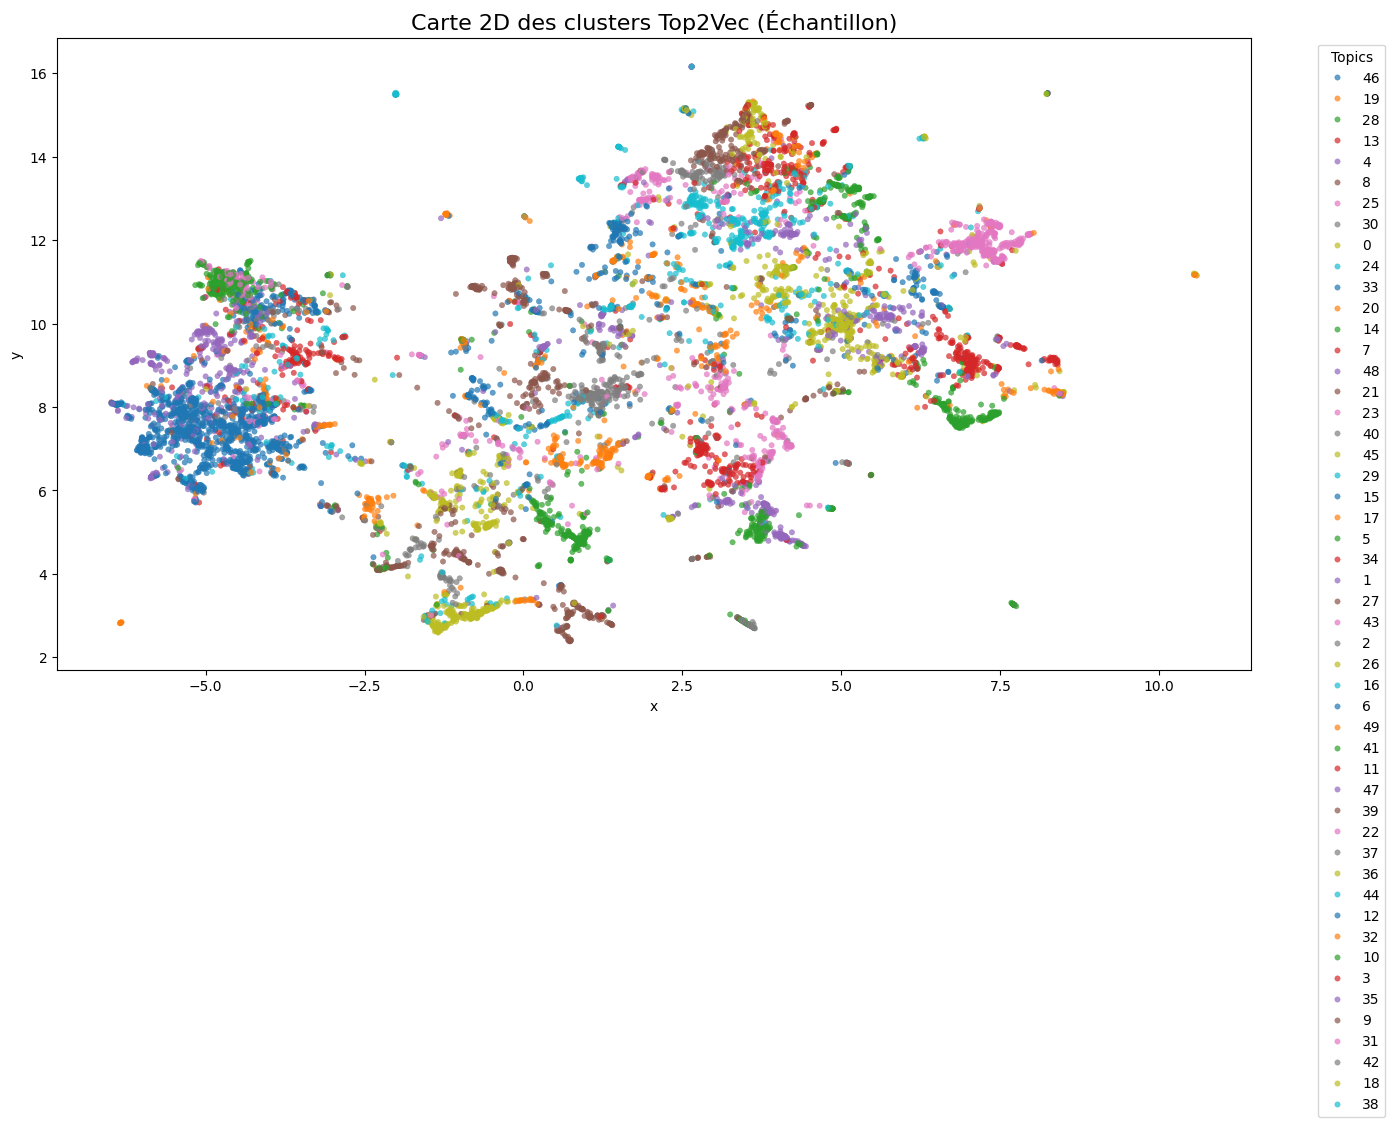

In [6]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. On récupère les labels de tes 10 topics (grâce à ta classe !)
topic_labels, _ = models_topics.evaluate(docs)

# 2. On récupère les vecteurs originaux des documents calculés par Top2Vec
doc_vectors = models_topics.model.document_vectors

# --- OPTIMISATION ---
# Comme tu as ag_news (très grand), on va prendre un échantillon de 10 000 docs 
# pour que le graphique se génère en quelques secondes plutôt qu'en 10 minutes.
sample_size = min(10000, len(docs))
doc_vectors_sample = doc_vectors[:sample_size]
labels_sample = topic_labels[:sample_size]

# 3. On utilise UMAP pour réduire les vecteurs (ex: 300 dimensions) en 2 dimensions (X, Y)
print("Réduction UMAP en 2D en cours... (ça prend quelques secondes)")
reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
embeddings_2d = reducer.fit_transform(doc_vectors_sample)

# 4. On prépare les données pour l'affichage
df_plot = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'Topic': labels_sample
})

# On filtre les "outliers" (topic -1) pour voir uniquement les vrais clusters
df_plot = df_plot[df_plot['Topic'] != -1]
# Optionnel : si on veut s'assurer que Topic est traité comme une catégorie
df_plot['Topic'] = df_plot['Topic'].astype(str) 

# 5. On dessine le graphique
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_plot, 
    x='x', 
    y='y', 
    hue='Topic', 
    palette='tab10', # Palette de 10 couleurs distinctes
    s=15, # Taille des points
    alpha=0.7, # Transparence pour mieux voir les superpositions
    edgecolor=None
)

plt.title("Carte 2D des clusters Top2Vec (Échantillon)", fontsize=16)
plt.legend(title='Topics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()